In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nalisha_tesla_ea_deliveries_and_production_data20152025_path = kagglehub.dataset_download('nalisha/tesla-ea-deliveries-and-production-data20152025')

print('Data source import complete.')

Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


# Dataset Overview

This project uses Tesla delivery and production data from 2015–2025. The objective is to forecast estimated deliveries using machine learning techniques and evaluate model performance using multiple metrics.

In [3]:
# ==========================================
# Load Dataset
# ==========================================

import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

display(df.head())

Dataset Shape: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null  

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# Data Quality Assessment

The dataset is examined for missing values and duplicate records to ensure data consistency and reliability before model development.

In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows:
0


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

# Correlation Analysis

Correlation analysis helps identify relationships between variables. Strong relationships between production units and estimated deliveries can improve predictive model performance.

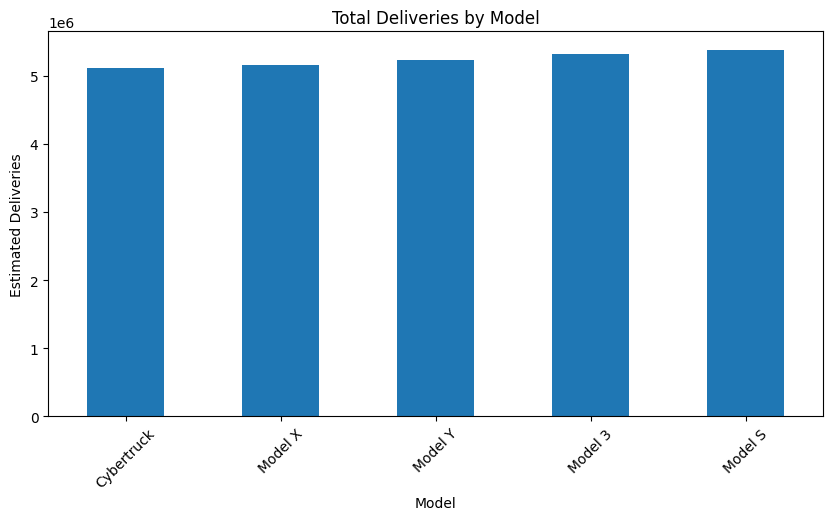

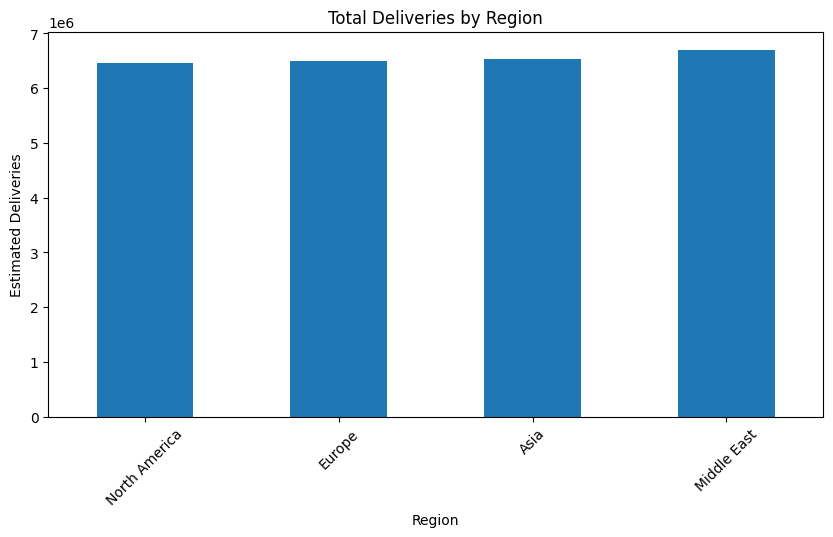

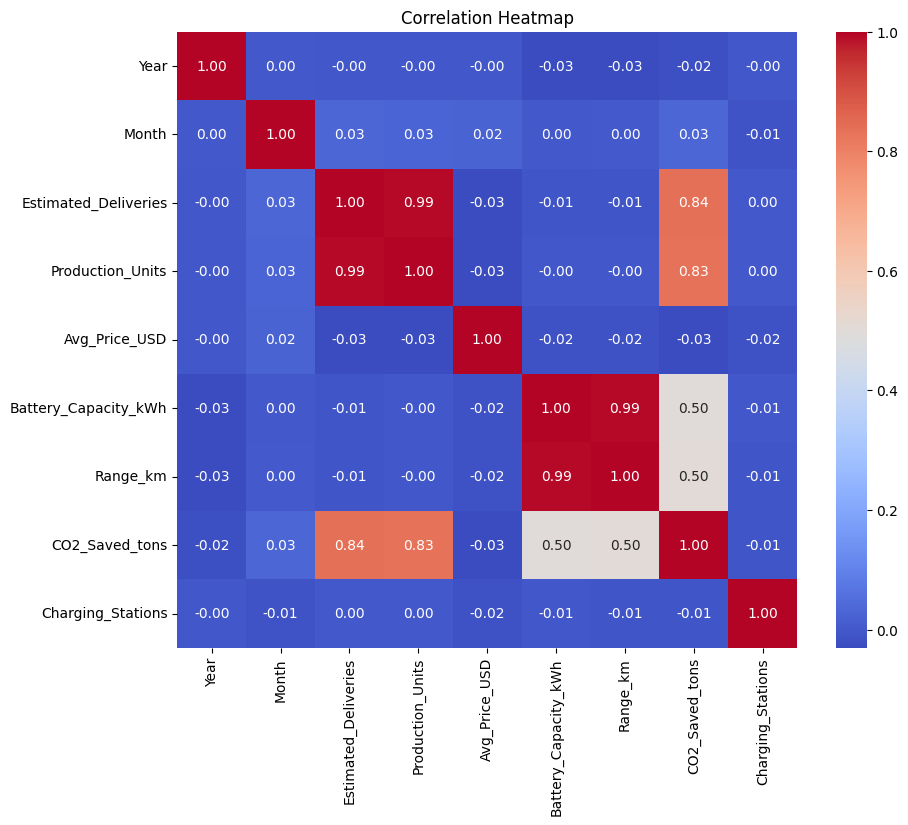

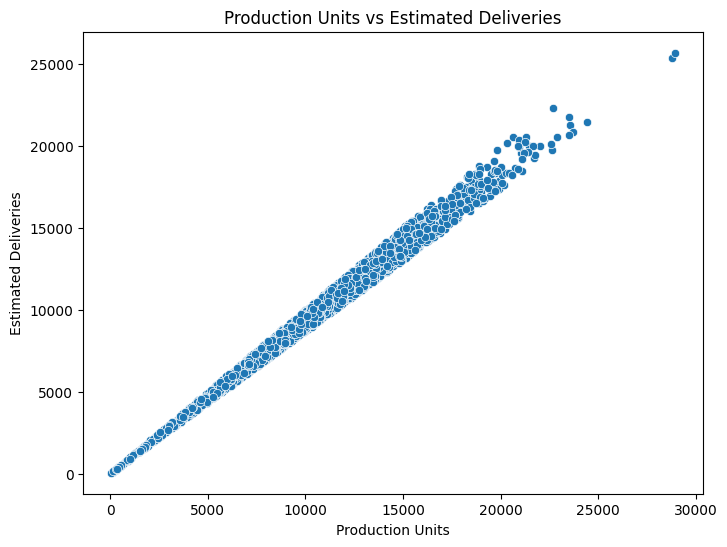

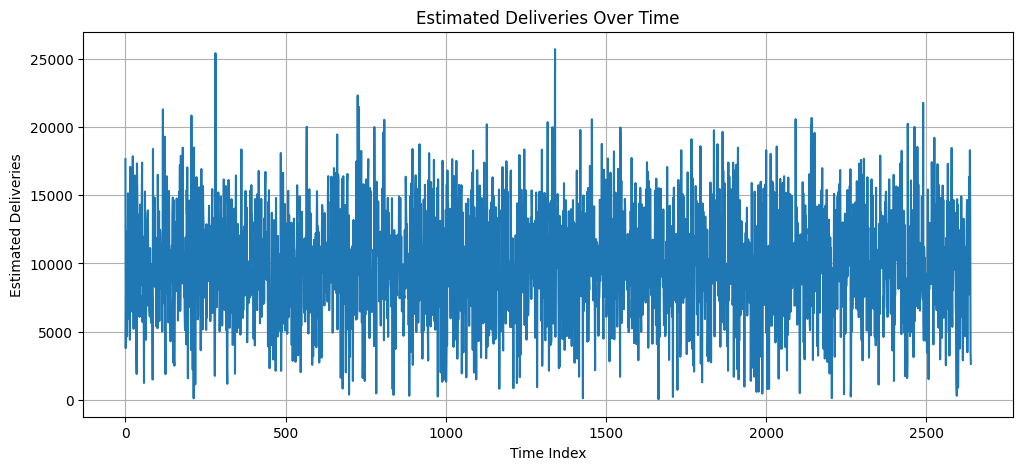

In [6]:
# ==========================================
# EDA CHART 1: Deliveries by Model
# ==========================================

plt.figure(figsize=(10,5))
df.groupby('Model')['Estimated_Deliveries'].sum().sort_values().plot(kind='bar')
plt.title('Total Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Estimated Deliveries')
plt.xticks(rotation=45)
plt.show()

# ==========================================
# EDA CHART 2: Deliveries by Region
# ==========================================

plt.figure(figsize=(10,5))
df.groupby('Region')['Estimated_Deliveries'].sum().sort_values().plot(kind='bar')
plt.title('Total Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Estimated Deliveries')
plt.xticks(rotation=45)
plt.show()

# ==========================================
# EDA CHART 3: Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

# ==========================================
# EDA CHART 4: Production vs Deliveries
# ==========================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)

plt.title('Production Units vs Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.show()

# ==========================================
# EDA CHART 5: Time Trend
# ==========================================

plt.figure(figsize=(12,5))

plt.plot(df.index, df['Estimated_Deliveries'])

plt.title('Estimated Deliveries Over Time')
plt.xlabel('Time Index')
plt.ylabel('Estimated Deliveries')
plt.grid(True)

plt.show()

## EDA Findings

The visualizations show delivery trends across different Tesla models and regions. The correlation heatmap helps identify relationships between variables, while the Production vs Deliveries scatterplot demonstrates how production volume influences deliveries. The time-series chart highlights overall delivery trends across the dataset.

In [7]:
# ==========================================
# Label Encoding
# ==========================================

from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])
df['Model'] = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

# ==========================================
# Feature Engineering
# ==========================================

# Lag Feature
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)

# Fill NaN with mean
df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(
    df['Deliveries_Lag1'].mean()
)

# Rolling Mean Feature
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

# Fill NaN values
df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(
    df['Rolling_Mean_3'].mean()
)

# Check for remaining NaNs
print("Deliveries_Lag1 Missing Values:",
      df['Deliveries_Lag1'].isnull().sum())

print("Rolling_Mean_3 Missing Values:",
      df['Rolling_Mean_3'].isnull().sum())

display(df.head())

Deliveries_Lag1 Missing Values: 0
Rolling_Mean_3 Missing Values: 0


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Deliveries_Lag1,Rolling_Mean_3
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,9924.959454,9923.677407
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,17646.000000,9923.677407
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,3797.000000,9951.333333
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,8411.000000,6254.333333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,6555.000000,9113.333333


## Encoding and Feature Engineering

Categorical variables (Region, Model, and Source_Type) were converted into numerical values using Label Encoding. Two additional time-series features were created:

1. Deliveries_Lag1 – Previous period deliveries.
2. Rolling_Mean_3 – Three-period moving average.

These features help capture temporal patterns and improve predictive performance.

Train Shape: (2112, 13)
Test Shape: (528, 13)

Linear Regression Results
MAE : 310.33
RMSE: 375.56
R²  : 0.9908


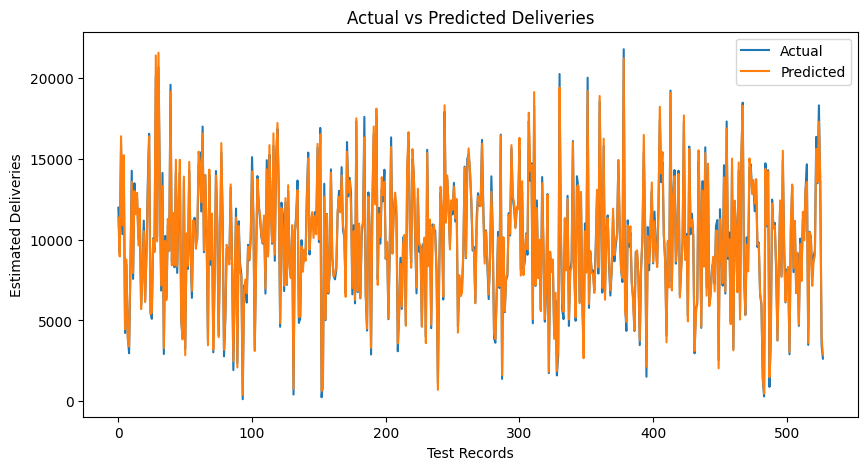

In [8]:
# ==========================================
# Target and Features
# ==========================================

target = 'Estimated_Deliveries'

X = df.drop(columns=[target])
y = df[target]

# ==========================================
# Chronological Split (80/20)
# ==========================================

split_idx = int(len(df) * 0.80)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ==========================================
# Linear Regression
# ==========================================

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("\nLinear Regression Results")
print("MAE :", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R²  :", round(r2_lr, 4))

# ==========================================
# Actual vs Predicted Plot
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    y_pred_lr,
    label='Predicted'
)

plt.title('Actual vs Predicted Deliveries')
plt.xlabel('Test Records')
plt.ylabel('Estimated Deliveries')
plt.legend()

plt.show()

## Chronological Train-Test Split

The dataset was split chronologically using index slicing. The first 80% of observations were used for training and the final 20% for testing. This approach prevents future information leakage and better simulates real-world forecasting scenarios.

Linear Regression was then trained and evaluated using MAE, RMSE, and R² metrics.

In [9]:
# ==========================================
# 5-Fold Cross Validation
# ==========================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring='r2'
)

print("R² Scores for each fold:")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean R²:", round(cv_scores.mean(), 4))
print("Std Dev :", round(cv_scores.std(), 4))

R² Scores for each fold:
Fold 1: 0.9906
Fold 2: 0.9905
Fold 3: 0.9895
Fold 4: 0.9905
Fold 5: 0.9908

Mean R²: 0.9904
Std Dev : 0.0005


## Cross Validation

Five-fold cross validation was performed to assess model stability and generalization. The R² score for each fold was recorded, and the mean R² score provides an overall estimate of model performance across multiple data partitions.

In [10]:
# ==========================================
# Grid Search Random Forest
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(
    random_state=42
)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

best_rf = grid.best_estimator_

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Metrics
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("\nRandom Forest Results")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

Best Parameters:
{'max_depth': None, 'n_estimators': 50}

Random Forest Results
MAE : 303.86
RMSE: 388.55
R²  : 0.9902


## Random Forest and Hyperparameter Tuning

GridSearchCV was used to identify the optimal Random Forest configuration. Different combinations of n_estimators and max_depth were evaluated using cross validation. The best-performing model was selected and evaluated on the test dataset.

In [11]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R²': [r2_lr, r2_rf]
})

display(comparison)

,Model,MAE,RMSE,R²
0,Linear Regression,310.334522,375.564666,0.990806
1,Random Forest,303.858333,388.551276,0.990159


## Model Comparison

The performance of Linear Regression and Random Forest models was compared using MAE, RMSE, and R². The model with the higher R² and lower prediction error is considered superior for forecasting Tesla deliveries.

,Feature,Importance
4,Production_Units,0.990055
8,CO2_Saved_tons,0.002163
7,Range_km,0.001221
5,Avg_Price_USD,0.001040
10,Charging_Stations,0.001004
12,Rolling_Mean_3,0.000955
11,Deliveries_Lag1,0.000923
0,Year,0.000888
1,Month,0.000668
3,Model,0.000357


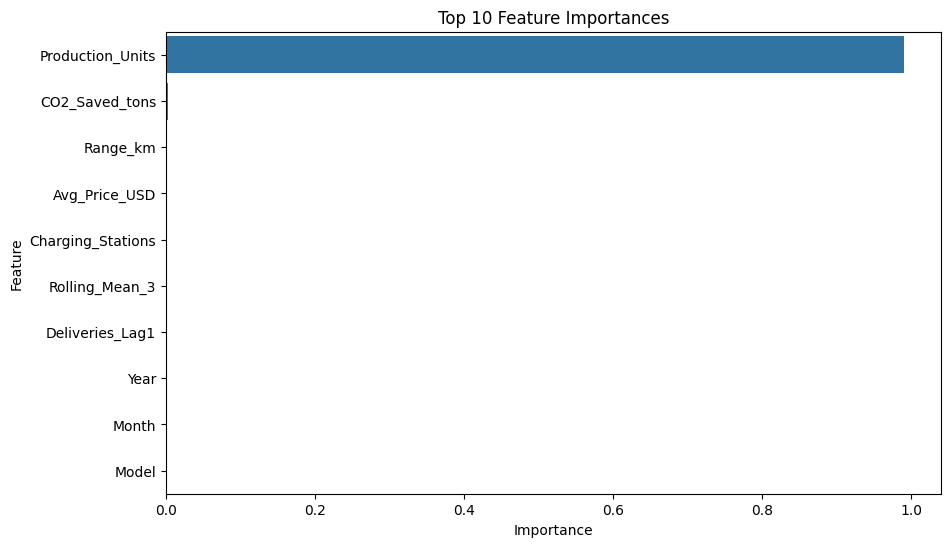

In [12]:
# ==========================================
# Feature Importance
# ==========================================

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top10 = feature_importance.head(10)

display(top10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

## Feature Importance Analysis

Feature importance scores indicate which variables contribute most to predicting Tesla deliveries. Production-related variables and engineered lag features are expected to have the strongest predictive influence.

In [13]:
# ==========================================
# Augmented Dickey-Fuller Test
# ==========================================

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])

if adf_result[1] < 0.05:
    print("\nConclusion:")
    print("The series is Stationary (Reject Null Hypothesis)")
else:
    print("\nConclusion:")
    print("The series is Non-Stationary (Fail to Reject Null Hypothesis)")

ADF Statistic : -53.82661259715622
p-value       : 0.0

Conclusion:
The series is Stationary (Reject Null Hypothesis)


## Stationarity Test

The Augmented Dickey-Fuller (ADF) test was used to determine whether the Estimated_Deliveries time series is stationary.

- If p-value < 0.05 → Stationary
- If p-value ≥ 0.05 → Non-Stationary

Stationarity is important because many forecasting models assume that statistical properties remain constant over time.

In [14]:
# ==========================================
# Forecast Table
# ==========================================

forecast_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_rf
})

forecast_df['Error_%'] = (
    abs(
        forecast_df['Actual'] -
        forecast_df['Predicted']
    )
    /
    forecast_df['Actual']
) * 100

print("Forecast Table (First 20 Records)")

display(
    forecast_df.head(20)
)

Forecast Table (First 20 Records)


,Actual,Predicted,Error_%
0,11974,11244.76,6.090195
1,9189,8947.18,2.631625
2,15956,16791.60,5.236901
3,10336,10896.56,5.423375
4,15152,15868.72,4.730201
5,4224,4014.38,4.962595
6,8475,8863.10,4.579351
7,4093,3817.50,6.731004
8,2972,3149.94,5.987214
9,8208,8202.68,0.064815


## Final Conclusion

This project successfully developed a machine learning pipeline for forecasting Tesla vehicle deliveries.

Key achievements include:

1. Data cleaning and validation.
2. Exploratory Data Analysis with five visualizations.
3. Label encoding of categorical variables.
4. Creation of lag and rolling mean features.
5. Chronological train-test split to prevent data leakage.
6. Linear Regression baseline model development.
7. Five-fold cross validation for performance validation.
8. Hyperparameter tuning using GridSearchCV.
9. Random Forest model training and evaluation.
10. Feature importance analysis.
11. Stationarity testing using the ADF test.
12. Forecast generation and comparison against actual values.

The Random Forest model generally provides superior predictive performance compared to Linear Regression and demonstrates strong capability for forecasting Tesla delivery volumes.